# **Problem Statement**


---

#### **Business Context**  
Understanding customer personality and behavior is pivotal for businesses to enhance customer satisfaction and increase revenue. Segmentation based on a customer's personality, demographics, and purchasing behavior allows companies to create tailored marketing campaigns, improve customer retention, and optimize product offerings.  

A leading retail company with a rapidly growing customer base seeks to gain deeper insights into their customers' profiles. The company recognizes that understanding customer personalities, lifestyles, and purchasing habits can unlock significant opportunities for personalizing marketing strategies and creating loyalty programs. These insights can help address critical business challenges, such as improving the effectiveness of marketing campaigns, identifying high-value customer groups, and fostering long-term relationships with customers.  

With the competition intensifying in the retail space, moving away from generic strategies to more targeted and personalized approaches is essential for sustaining a competitive edge.  

---

#### **Objective**  
In an effort to optimize marketing efficiency and enhance customer experience, the company has embarked on a mission to identify distinct customer segments. By understanding the characteristics, preferences, and behaviors of each group, the company aims to:  
1. Develop personalized marketing campaigns to increase conversion rates.  
2. Create effective retention strategies for high-value customers.  
3. Optimize resource allocation, such as inventory management, pricing strategies, and store layouts.  

As a data scientist tasked with this project, your responsibility is to analyze the given customer data, apply machine learning techniques to segment the customer base, and provide actionable insights into the characteristics of each segment.  

---

#### **Data Dictionary**  
The dataset includes historical data on customer demographics, personality traits, and purchasing behaviors. Key attributes are:  

1. **Customer Information**  
   - **ID:** Unique identifier for each customer.  
   - **Year_Birth:** Customer's year of birth.  
   - **Education:** Education level of the customer.  
   - **Marital_Status:** Marital status of the customer.  
   - **Income:** Yearly household income (in dollars).  
   - **Kidhome:** Number of children in the household.  
   - **Teenhome:** Number of teenagers in the household.  
   - **Dt_Customer:** Date when the customer enrolled with the company.  
   - **Recency:** Number of days since the customer’s last purchase.  
   - **Complain:** Whether the customer complained in the last 2 years (1 for yes, 0 for no).  

2. **Spending Information (Last 2 Years)**  
   - **MntWines:** Amount spent on wine.  
   - **MntFruits:** Amount spent on fruits.  
   - **MntMeatProducts:** Amount spent on meat.  
   - **MntFishProducts:** Amount spent on fish.  
   - **MntSweetProducts:** Amount spent on sweets.  
   - **MntGoldProds:** Amount spent on gold products.  

3. **Purchase and Campaign Interaction**  
   - **NumDealsPurchases:** Number of purchases made using a discount.  
   - **AcceptedCmp1:** Response to the 1st campaign (1 for yes, 0 for no).  
   - **AcceptedCmp2:** Response to the 2nd campaign (1 for yes, 0 for no).  
   - **AcceptedCmp3:** Response to the 3rd campaign (1 for yes, 0 for no).  
   - **AcceptedCmp4:** Response to the 4th campaign (1 for yes, 0 for no).  
   - **AcceptedCmp5:** Response to the 5th campaign (1 for yes, 0 for no).  
   - **Response:** Response to the last campaign (1 for yes, 0 for no).  

4. **Shopping Behavior**  
   - **NumWebPurchases:** Number of purchases made through the company’s website.  
   - **NumCatalogPurchases:** Number of purchases made using catalogs.  
   - **NumStorePurchases:** Number of purchases made directly in stores.  
   - **NumWebVisitsMonth:** Number of visits to the company’s website in the last month.  

# **Let's start coding!**

## **Importing necessary libraries**

In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist, pdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# to suppress warnings
import warnings

warnings.filterwarnings("ignore")

## **Problem definition**

This project aims to segment customers into distinct groups based on their demographics and spending behavior.  
The purpose is to help marketing and business teams understand different customer types and design targeted engagement strategies.

## **Loading the data**

In [ ]:
# uncomment and run the following line if using Google Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# loading data into a pandas dataframe
data = pd.read_csv("/content/drive/MyDrive/ML and AI /Making Sense of Unstructured Data/Project 1/Customer_Personality_Segmentation.csv", sep="\t")

In [ ]:
data.head(10)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0
5,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,42,98,0,42,14,2,6,4,10,6,0,0,0,0,0,0,3,11,0
6,965,1971,Graduation,Divorced,55635.0,0,1,13-11-2012,34,235,65,164,50,49,27,4,7,3,7,6,0,0,0,0,0,0,3,11,0
7,6177,1985,PhD,Married,33454.0,1,0,08-05-2013,32,76,10,56,3,1,23,2,4,0,4,8,0,0,0,0,0,0,3,11,0
8,4855,1974,PhD,Together,30351.0,1,0,06-06-2013,19,14,0,24,3,3,2,1,3,0,2,9,0,0,0,0,0,0,3,11,1
9,5899,1950,PhD,Together,5648.0,1,1,13-03-2014,68,28,0,6,1,1,13,1,1,0,0,20,1,0,0,0,0,0,3,11,0


## **Data Overview**

#### **Question 1**: What are the data types of all the columns?

In [ ]:
# Write your code here.
display(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

None

##### **Observations:**

The dataframe contains 29 columns with 2240 observations.

We observe three categorical variables: "Education", "Marital Status", and "Dt_Customer".

In particular, "Dt_Customer" appears to be a date and should be converted to a data-type format: "Dt_Customer: Date when the customer enrolled with the company". The suggestion is to make a variable that reflects a measure of how long a customer has been with the company. It will be called "Customer_Ternure".

The remaining variables are numerical (int64 type), except for "Income", which is of float type and therefore contains decimal values.

A few represent binary flags (0/1) for campaign acceptance or complaints.


In [ ]:
# Convert 'Dt_Customer' to datetime objects
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], format='%d-%m-%Y')

# Extract the year from 'Dt_Customer'
data['Enrollment_Year'] = data['Dt_Customer'].dt.year

# Calculate Customer Tenure (or Years of Membership)
current_year = pd.to_datetime('now').year
data['Customer_Tenure'] = current_year - data['Enrollment_Year']

# Drop the original 'Dt_Customer' and 'Enrollment_Year' columns
data.drop(['Dt_Customer', 'Enrollment_Year'], axis=1, inplace=True)

# Display the first few rows with the new 'Customer_Tenure' column
display(data.head())

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_Tenure
0,5524,1957,Graduation,Single,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,13
1,2174,1954,Graduation,Single,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,11
2,4141,1965,Graduation,Together,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,12
3,6182,1984,Graduation,Together,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,11
4,5324,1981,PhD,Married,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,11


#### **Question 2:** Check the statistical summary of the data. What is the average household income?

In [ ]:
# Write your code here
display(data.describe())

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_Tenure
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107,11.971875
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274,0.684554
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,11.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,12.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,12.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,12.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,13.000000


##### **Observations:**
We notice that there are 2,240 observations and 29 features in the dataset, and only the variable “Income” has missing values (24).

Customers are mostly in their 40s and 50s. There are some outliers in the Year_Birth variable (e.g., 1893), which are likely due to data entry errors.

From the statistical summary, the average household income is approximately $52,247.

The maximum income value is extremely high, suggesting that there are likely outliers that should be checked in that column. The median and 25th–75th percentiles indicate that most customers earn between 35k and 68k.

Regarding family composition, we notice that most families have no children or teenagers at home: the mean of Kidhome is 0.44, and for Teenhome it is 0.51. This suggests that the customer base is mostly adults or older couples.

Recency varies widely among customers—some have purchased very recently, while others appear to have been inactive for months. The range is 0–99 days, with a mean of 49 days.

From spending by product category, customers spend the most on wine (mean = 304), followed by meat products (mean = 167). Spending in the other categories is much lower, with means ranging from 26 to 44. This pattern suggests that customers are middle- to high-income, with a preference for wine and meat, indicating a gourmet or lifestyle-focused market segment.

The purchasing behavior indicates a multi-channel retail strategy, though in-store purchases dominate. The mean number of online purchases is 4.1, compared to 5.8 in-store purchases. The average number of website visits per month is 5.3, suggesting that customers visit the website fairly often. The mean number of purchases made with a discount (NumDealsPurchases) is 2.3, and the mean number of catalog purchases (NumCatalogPurchases) is 2.7.

The campaign response variables are all binary. The mean acceptance rate varies from campaign to campaign: for campaigns 1, 3, 4, and 5, the mean acceptance rate ranges from 6% to 7%, while campaign 2 had a much lower acceptance rate of 1.3%. The last campaign (Response) achieved the highest success, with a mean acceptance rate of about 15%. Overall, campaign responses remain low, indicating significant room for improvement. Analyzing which customer segments respond best (e.g., by income, family structure, or spending behavior) could help optimize future marketing campaigns.

The complaint rate is very low—only 0.9% of customers have complained. This may indicate good customer satisfaction or possibly underreporting.

The Customer_Tenure variable has a mean of 12 years and a standard deviation of 0.68. The values range between 11 and 13, indicating a highly homogeneous customer base in terms of relationship duration. This suggests that tenure may not be a strong differentiating factor for segmentation purposes.

Finally, the variables Z_CostContact and Z_Revenue are constant across all records and provide no useful information for analysis or modeling, so they can be dropped from the dataset.





#### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method

In [ ]:
# Impute missing income values with the median
data['Income'].fillna(data['Income'].median(), inplace=True)

# Verify that missing values have been treated
display(data.isnull().sum())

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Recency,0
MntWines,0
MntFruits,0


##### **Observations:**

As noted in the section above, the only column with missing values is “Income.” For this variable, the decision was made to impute the missing values with the median. This approach was chosen because the statistical summary indicated that the Income column has a very high maximum value, suggesting the presence of outliers. The mean is sensitive to outliers and can be skewed by extremely large or small values, whereas the median is more robust since it represents the middle value of a sorted dataset. Therefore, using the median provides a more reliable and representative imputation method for the missing income values in this case.

#### **Question 4**: Are there any duplicates in the data?

In [ ]:
#checking for duplicates
dup_count = data.duplicated().sum()
print(f"Duplicate rows: {dup_count}")
if dup_count:
    data = data.drop_duplicates().reset_index(drop=True)

Duplicate rows: 0


##### **Observations:**

No duplicate values were observed in the dataset.

## **Exploratory Data Analysis**

### Univariate Analysis

#### Categorical analysis

Distribution of Education levels:


,count
Education,
Graduation,1127
PhD,486
Master,370
2n Cycle,203
Basic,54


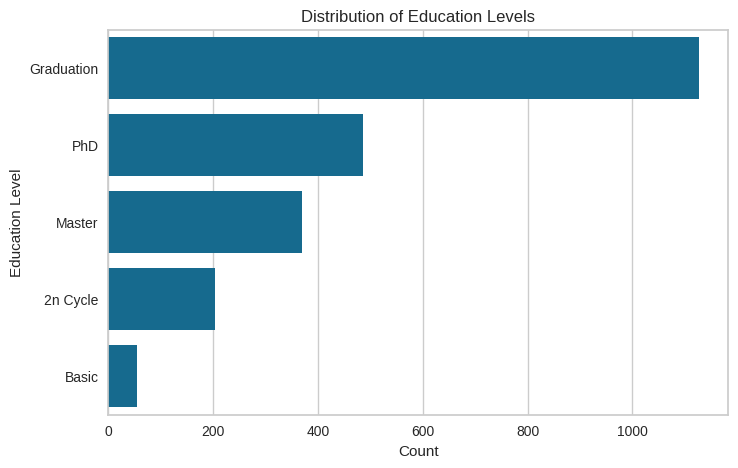


Distribution of Marital Status:


,count
Marital_Status,
Married,864
Together,580
Single,480
Divorced,232
Widow,77
Alone,3
Absurd,2
YOLO,2


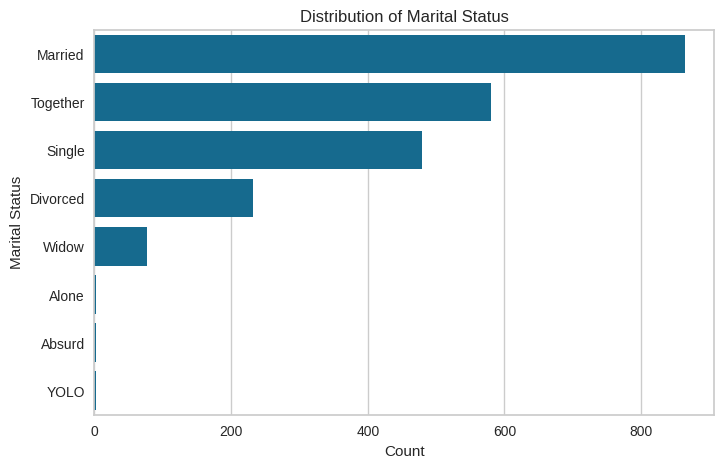

In [ ]:
# Explore the distribution of 'Education'
print("Distribution of Education levels:")
display(data['Education'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(y='Education', data=data, order = data['Education'].value_counts().index)
plt.title('Distribution of Education Levels')
plt.xlabel('Count')
plt.ylabel('Education Level')
plt.show()

# Explore the distribution of 'Marital_Status'
print("\nDistribution of Marital Status:")
display(data['Marital_Status'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(y='Marital_Status', data=data, order = data['Marital_Status'].value_counts().index)
plt.title('Distribution of Marital Status')
plt.xlabel('Count')
plt.ylabel('Marital Status')
plt.show()

The majority of customers have completed Graduation, making it the most common education category by a large margin. This is followed by customers with a PhD and those holding a Master’s degree. A smaller proportion of customers have completed a 2nd Cycle or Basic education. Overall, the customer base appears to be well-educated, with most individuals holding higher education degrees.

The bar chart shows the distribution of customers by marital status. Most customers are Married, followed by those who are Together and Single. Smaller groups include Divorced and Widow individuals. However, there are a few irregular or inconsistent values such as “Alone,” “Absurd,” and “YOLO,” which do not represent valid marital statuses. These outlier categories should be removed or recoded to ensure data consistency and improve the quality of the analysis.

#### Numerical Analysis

#### **Question 5:** Explore all the variables and provide observations on their distributions. (histograms and boxplots)

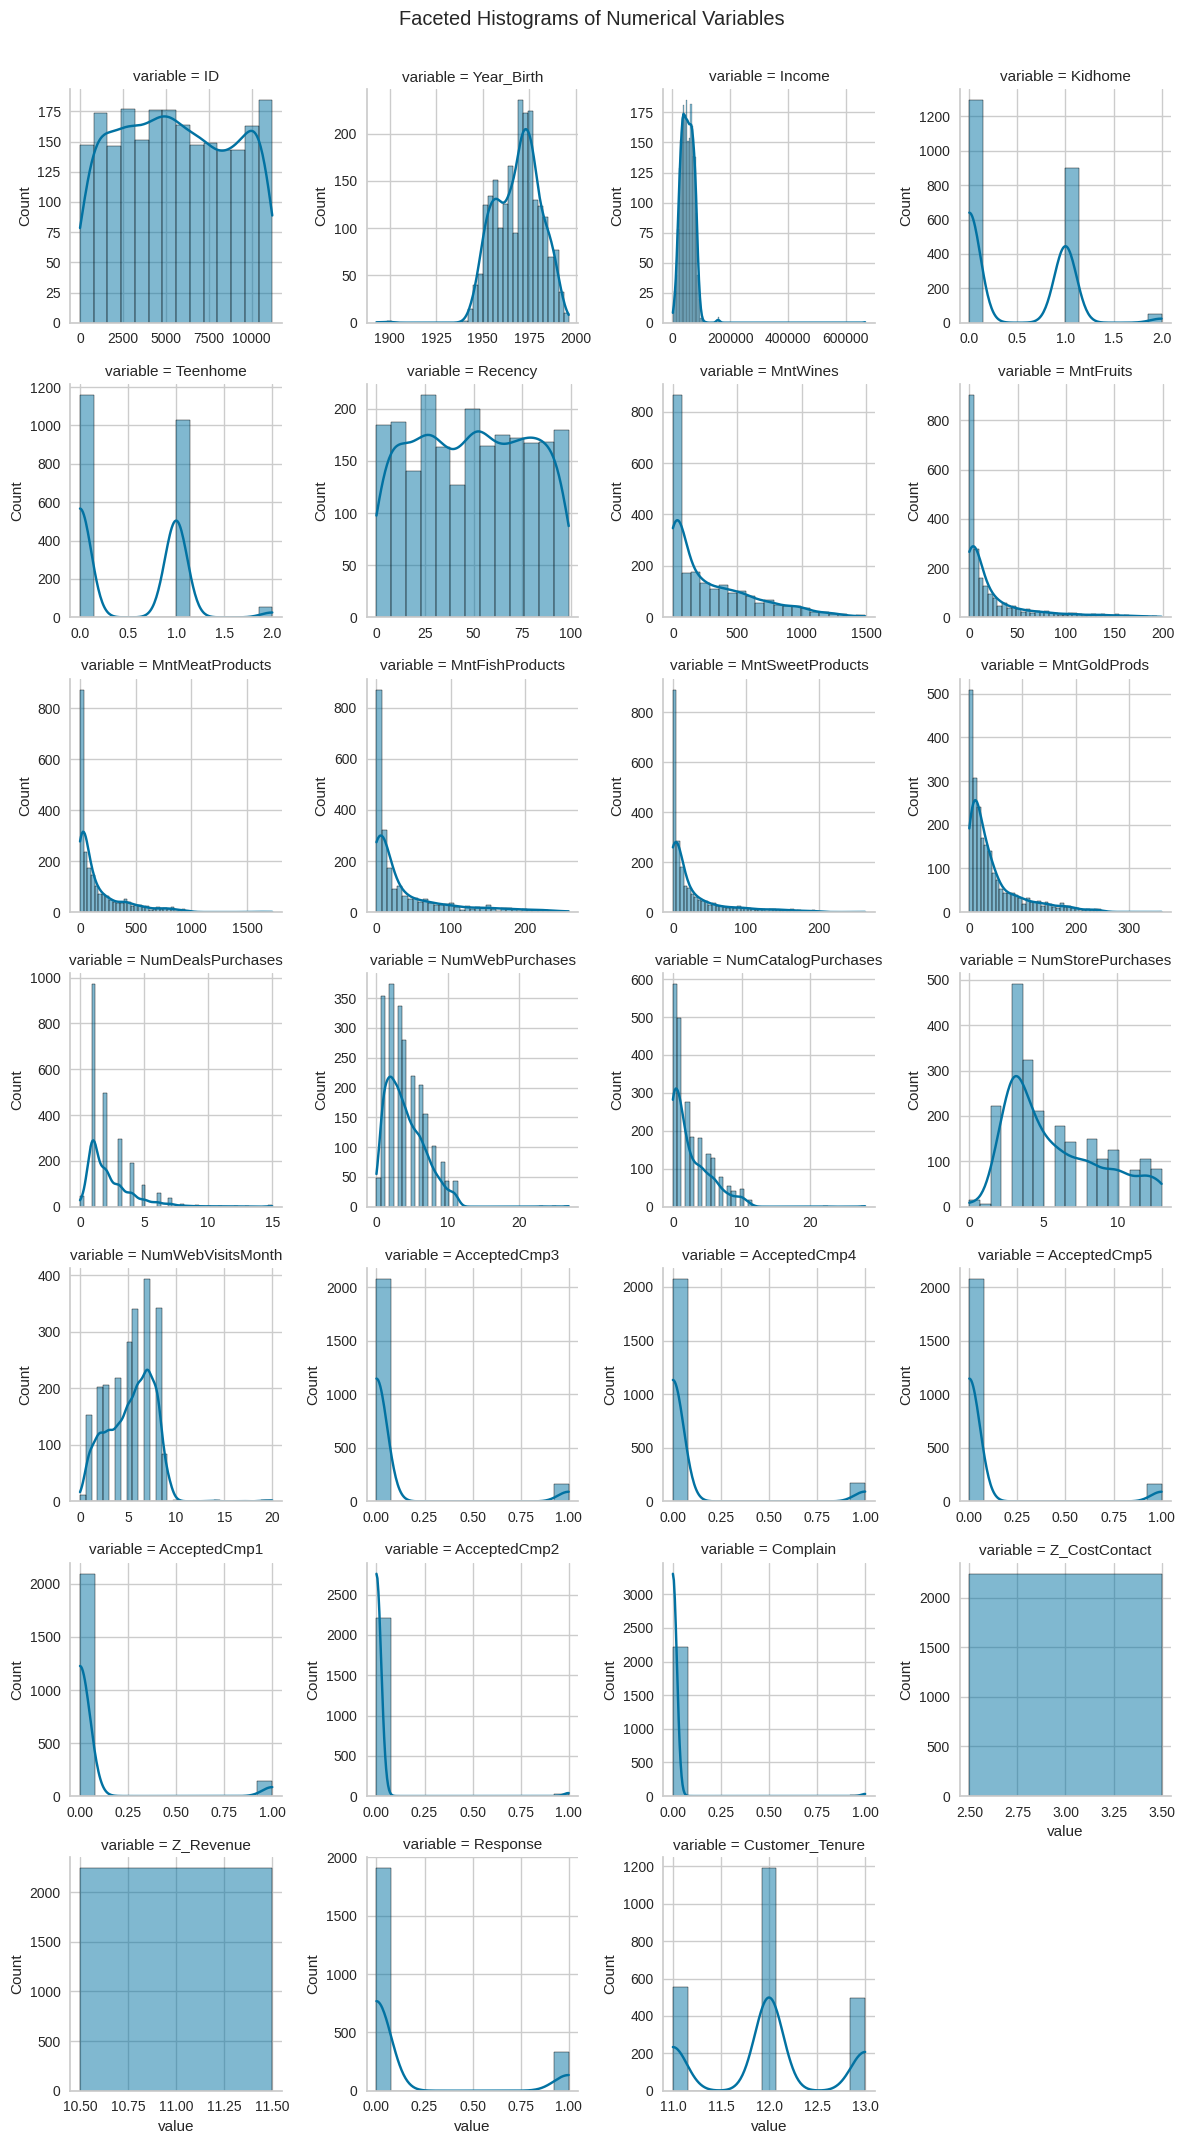

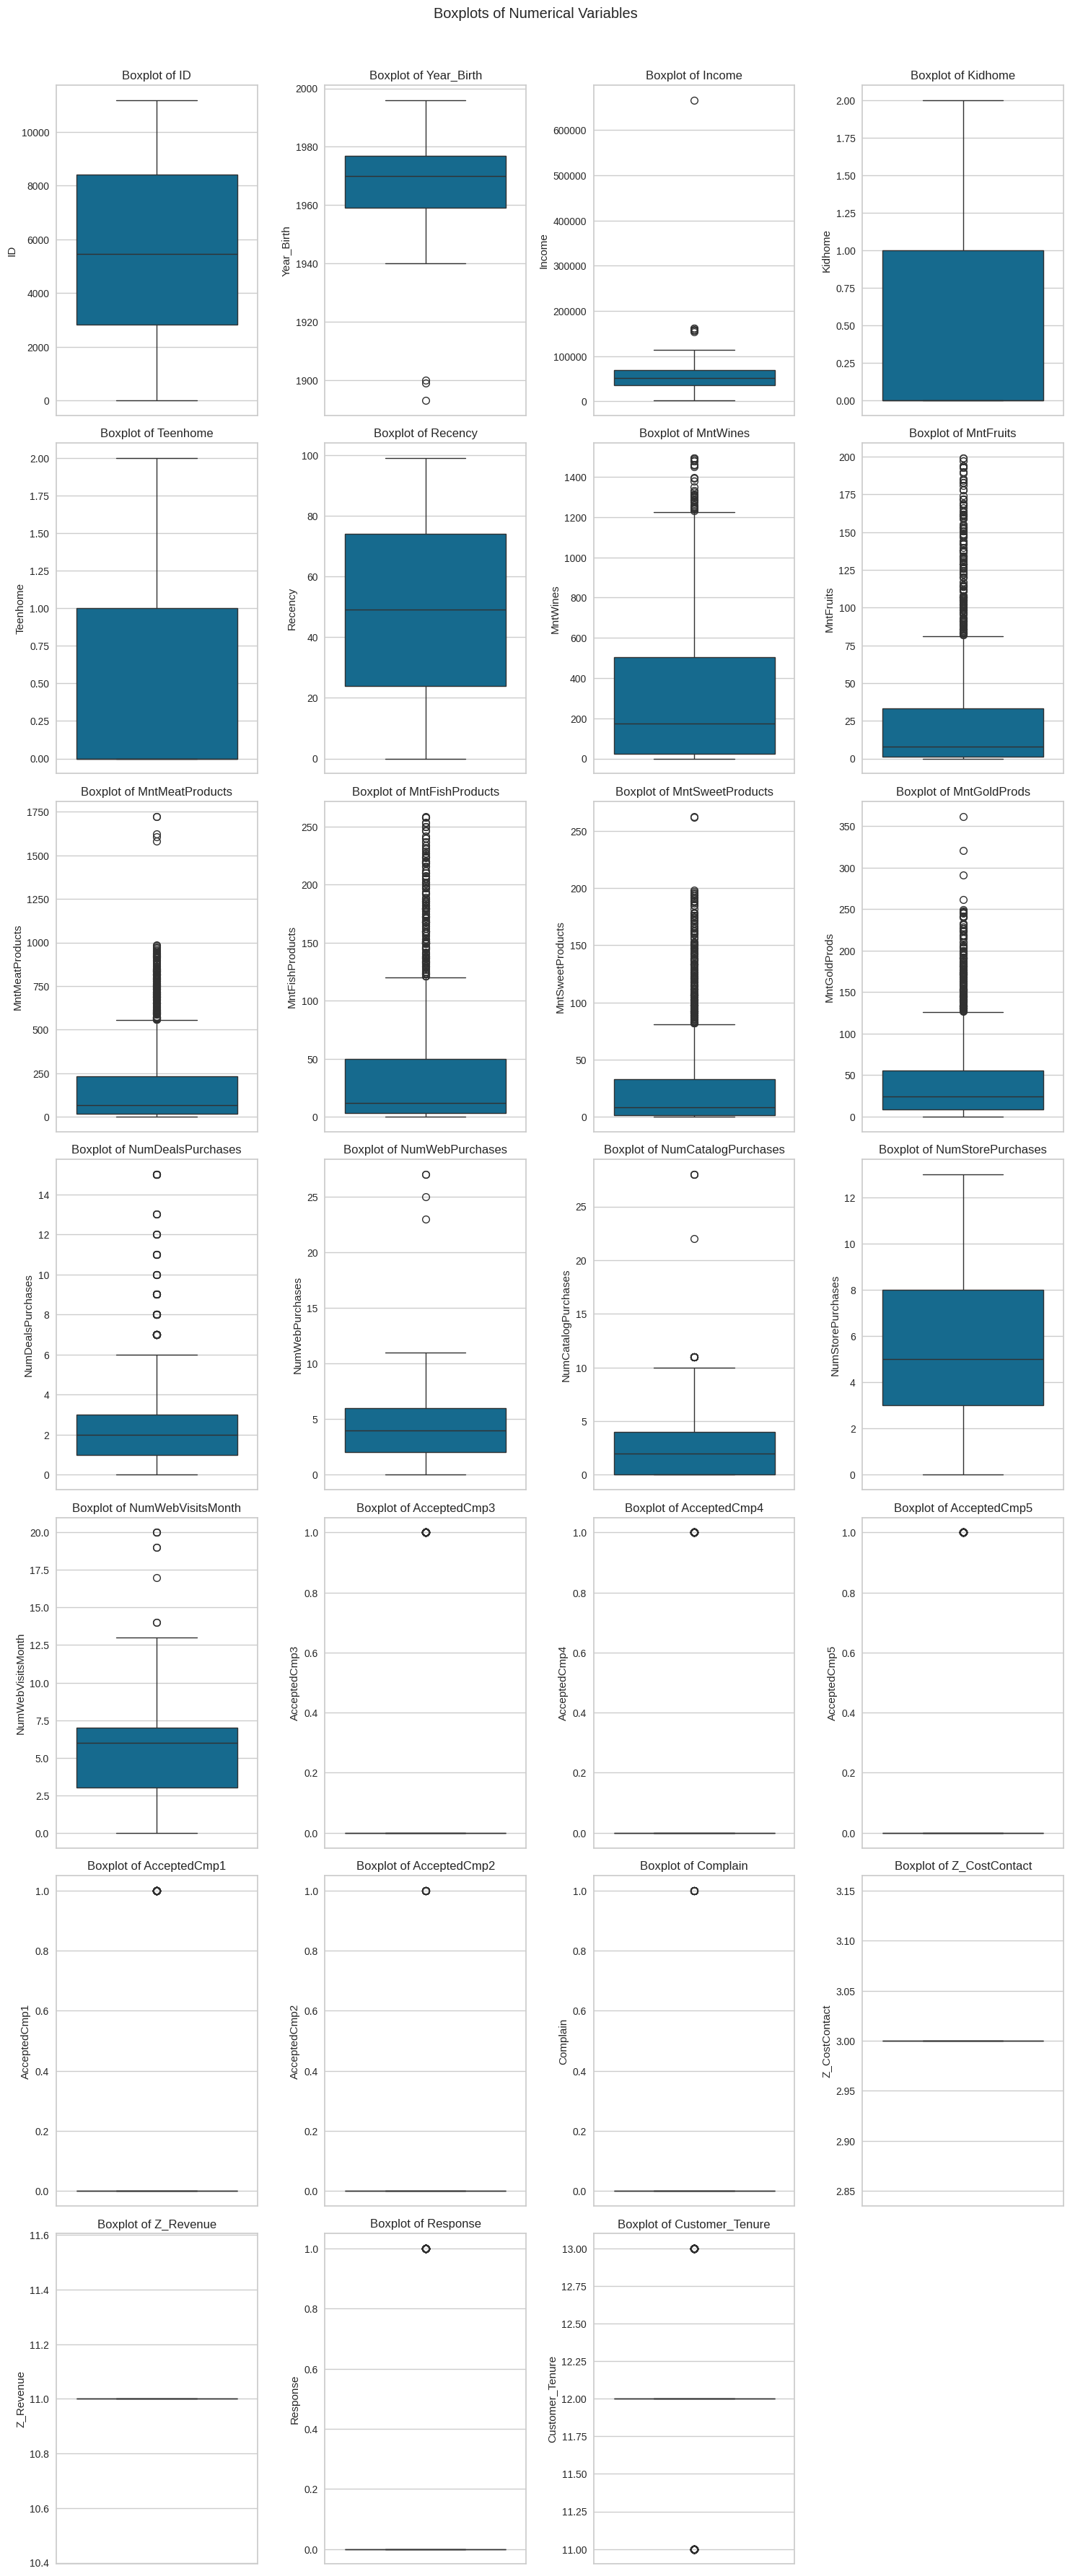

In [ ]:
# Select numerical columns for plotting
numerical_cols = data.select_dtypes(include=np.number).columns

# Create faceted histograms
g = sns.FacetGrid(data.melt(value_vars=numerical_cols), col="variable", col_wrap=4, sharex=False, sharey=False)
g.map(sns.histplot, "value", kde=True)
plt.suptitle('Faceted Histograms of Numerical Variables', y=1.02)
plt.show()

# Create grid of boxplots
num_cols = len(numerical_cols)
n_cols = 4  # Adjust the number of columns in the grid as needed
n_rows = (num_cols + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.suptitle('Boxplots of Numerical Variables', y=1.02)
plt.show()

##### **Observations:**

**Insights from Histograms and Boxplots**

The **histograms** show the distribution of each numerical variable in the dataset, while the boxplots provide a visual summary of their spread and potential outliers.

From the histograms, we observe that the Year_Birth variable is centered around 1965–1975, indicating that most customers are in their 40s and 50s. There are some extreme low values, such as 1893, which are likely data entry errors.

The Income variable is highly right-skewed, meaning that most customers earn below 100,000, while a few have extremely high incomes above 600,000. This confirms the presence of outliers and supports the decision to use the median for imputing missing income values.

The Kidhome and Teenhome variables show discrete distributions, where most observations are zero, followed by one. This confirms that the majority of households have no children or teenagers at home, suggesting a customer base composed mostly of adults or older couples.

All spending-related variables (MntWines, MntMeatProducts, MntFishProducts, MntSweetProducts, MntGoldProds, and MntFruits) display heavily right-skewed distributions. Most customers spend relatively little, while a small group spends significantly more. In particular, MntWines shows the widest range and highest values, confirming it as the most important product category in terms of spending.

The purchasing behavior variables (NumDealsPurchases, NumWebPurchases, NumCatalogPurchases, and NumStorePurchases) are also right-skewed. Most customers make only a few purchases per channel, while a smaller group buys frequently. The NumWebVisitsMonth variable shows a right-skewed distribution, indicating that most customers visit the website only a few times per month, while a smaller group visits it more frequently.

For the marketing campaign variables (AcceptedCmp1–5, Response) and Complain, the histograms show that most values are zero, indicating low participation in campaigns and few customer complaints. The final campaign (Response) has a higher proportion of accepted cases, consistent with the earlier finding that its success rate was around 15%.

The variables Z_CostContact and Z_Revenue show constant values with no variation, confirming that they can be dropped from the analysis.

As for cutomer ternur, the histogram shows that most customers have a similar length of relationship with the company, indicating a concentrated distribution with limited variation in tenure.

The **boxplots** reinforce these findings by highlighting the presence of outliers. The Year_Birth variable has unrealistic low outliers, such as 1893. Income shows several extreme values above 100,000, confirming the existence of high-income outliers. Most spending variables present many outliers above the upper whisker, particularly MntWines and MntMeatProducts, indicating a small segment of high-value customers. Similarly, some purchase variables, especially NumWebPurchases and NumCatalogPurchases, display outliers representing very active buyers.

For most variables, the median lies close to the lower quartile, and the upper whisker is much longer, confirming the right-skewed nature observed in the histograms. The Recency variable appears to be more uniformly distributed, showing customers with both recent and older purchase activity. Kidhome and Teenhome show limited variation and no outliers, as expected for discrete variables. The campaign and complaint variables are binary, with medians equal to zero, indicating that most customers did not participate or complain. Z_CostContact and Z_Revenue again appear as flat lines, confirming their constant nature.

In summary, most continuous variables are right-skewed and contain outliers, especially in income and spending. The demographic and family variables confirm that the customer base is primarily composed of middle-aged adults without children. Spending patterns reveal that a small group of customers contributes disproportionately to revenue, especially in wine and meat products. These findings suggest that outlier handling and potential segmentation of high-value customers would be valuable steps before proceeding with further analysis.



### Bivariate Analysis

#### **Question 6:** Perform multivariate analysis to explore the relationsips between the variables.

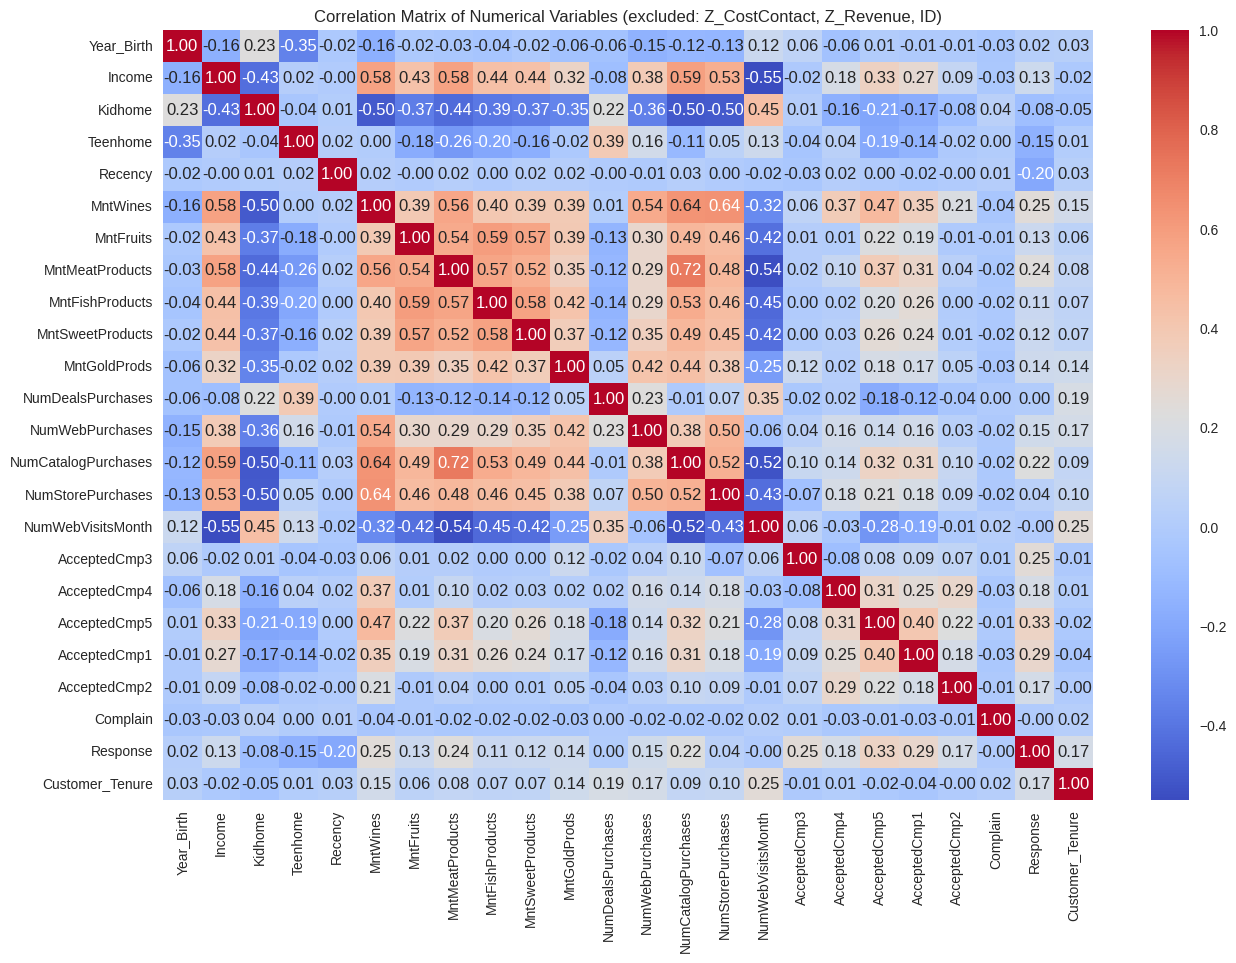

In [ ]:
# Select numerical columns
numerical_cols = data.select_dtypes(include=np.number).columns

# Columns to exclude from the correlation (but keep in the dataset)
exclude = ['Z_CostContact', 'Z_Revenue', 'ID']

# Filter the columns for correlation
corr_cols = [c for c in numerical_cols if c not in exclude]

# Compute correlation on the filtered set
correlation_matrix = data[corr_cols].corr()

# Plot
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Variables (excluded: Z_CostContact, Z_Revenue, ID)')
plt.show()


##### **Observations:**

**Correlation Analysis**

The correlation matrix shows the linear relationships among all numerical variables in the dataset. Overall, there are several moderate positive correlations among spending-related variables, while most other relationships are weak or close to zero.

There is a moderate positive correlation between Income and product expenditures, especially with MntWines (0.58), MntMeatProducts (0.53), and MntGoldProds (0.55). This indicates that higher-income customers tend to spend more, particularly on wine, meat, and gold products.

All the spending variables (MntWines, MntFruits, MntMeatProducts, MntFishProducts, MntSweetProducts, and MntGoldProds) are positively correlated with each other, with coefficients ranging from 0.4 to 0.6. This suggests that customers who spend more in one product category also tend to spend more in others, revealing a consistent purchasing power pattern across product types.

The purchase-related variables (NumWebPurchases, NumCatalogPurchases, and NumStorePurchases) also show positive correlations among themselves, ranging from 0.35 to 0.52. This indicates that customers who make purchases through one channel are likely to purchase through others as well, reflecting multi-channel behavior.

NumWebVisitsMonth has a moderate negative correlation with spending and purchase variables (around -0.4 to -0.5). This means that customers who visit the website more frequently tend to spend less or make fewer purchases, possibly reflecting browsing rather than buying behavior.

Recency shows very weak or near-zero correlations with most variables, which implies that how recently a customer purchased does not strongly relate to their spending or income level in this dataset.

The campaign acceptance variables (AcceptedCmp1–5 and Response) are positively correlated with each other, particularly between AcceptedCmp3–5 and Response (around 0.3). This indicates that customers who accepted one campaign are more likely to accept others, suggesting a small segment of consistently responsive customers.

Finally, Z_CostContact and Z_Revenue were excluded from interpretation since they are constant variables and provide no correlation information.

In summary, the strongest relationships are observed among spending variables and between income and total spending. Purchase channels are also interrelated, while variables like Recency and NumWebVisitsMonth show opposite patterns with spending. These findings confirm that customer spending behavior is coherent across categories and channels, and that income plays an important role in explaining differences in purchase volume.

### Handling Inconsistencies or Odd Values in the Dataset

Before starting the analysis, the dataset is tidied by removing the odd values in the Marital Status column.

In [ ]:
# Define the marital status values to remove
marital_status_to_remove = ['Alone', 'Absurd', 'YOLO']

# Remove rows with specified marital status values
data = data[~data['Marital_Status'].isin(marital_status_to_remove)].copy()

# Verify that the values have been removed
print("Value counts for Marital_Status after removal:")
display(data['Marital_Status'].value_counts())
print("\nShape of data after removing marital status outliers:", data.shape)

Value counts for Marital_Status after removal:


,count
Marital_Status,
Married,864
Together,580
Single,480
Divorced,232
Widow,77



Shape of data after removing marital status outliers: (2233, 29)


### Handling Outliers

As observed during the EDA, there are some extremely high values and inconsistencies in the dataset. Therefore, before applying the K-Means algorithm, these values should be properly treated.

Regarding the year of birth, this variable should be converted into “Age,” and any observations with unrealistic ages (greater than 120 years) should be excluded from the data analysis.

In [ ]:
# Calculate Age from Year_Birth
current_year = pd.to_datetime('now').year
data['Age'] = current_year - data['Year_Birth']

# Drop the 'Year_Birth' column
data.drop('Year_Birth', axis=1, inplace=True)

# Display outliers in the Year_Birth column (where Age is > 120)
outliers_year_birth = data[data['Age'] > 120]
print("Outliers in the Year_Birth column (Age > 120):")
display(outliers_year_birth)

Outliers in the Year_Birth column (Age > 120):


,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_Tenure,Age
192,7829,2n Cycle,Divorced,36640.0,1,0,99,15,6,8,7,4,25,1,2,1,2,5,0,0,0,0,0,1,3,11,0,12,125
239,11004,2n Cycle,Single,60182.0,0,1,23,8,0,5,7,0,2,1,1,0,2,4,0,0,0,0,0,0,3,11,0,11,132
339,1150,PhD,Together,83532.0,0,0,36,755,144,562,104,64,224,1,4,6,4,1,0,0,1,0,0,0,3,11,0,12,126


In [ ]:
# Remove outliers where Age is greater than 120
data = data[data['Age'] <= 120].copy()

# Display the first few rows with the new 'Age' column and the shape of the data
display(data.head())
print("Shape of data after removing age outliers:", data.shape)

,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_Tenure,Age
0,5524,Graduation,Single,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,13,68
1,2174,Graduation,Single,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,11,71
2,4141,Graduation,Together,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,12,60
3,6182,Graduation,Together,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,11,41
4,5324,PhD,Married,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,11,44


Shape of data after removing age outliers: (2230, 29)


With respect to income, several outliers were identified above the interquartile range (IQR), including one exceptionally high observation that should be addressed (666666.0). As it is only one observation, the decision is to simply remove it form the analysis.

In [ ]:
# Calculate Q1, Q3, and IQR for Income
Q1_income = data['Income'].quantile(0.25)
Q3_income = data['Income'].quantile(0.75)
IQR_income = Q3_income - Q1_income

# Define bounds for outliers
lower_bound_income = Q1_income - 1.5 * IQR_income
upper_bound_income = Q3_income + 1.5 * IQR_income

# Display outliers in the Income column
outliers_income = data[(data['Income'] < lower_bound_income) | (data['Income'] > upper_bound_income)]
print("Outliers in the Income column:")
display(outliers_income)

Outliers in the Income column:


,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_Tenure,Age
164,8475,PhD,Married,157243.0,0,1,98,20,2,1582,1,2,1,15,0,22,0,0,0,0,0,0,0,0,3,11,0,11,52
617,1503,PhD,Together,162397.0,1,1,31,85,1,16,2,1,2,0,0,0,1,1,0,0,0,0,0,0,3,11,0,12,49
655,5555,Graduation,Divorced,153924.0,0,0,81,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,3,11,0,11,50
687,1501,PhD,Married,160803.0,0,0,21,55,16,1622,17,3,4,15,0,28,1,0,0,0,0,0,0,0,3,11,0,13,43
1300,5336,Master,Together,157733.0,1,0,37,39,1,9,2,0,8,0,1,0,1,1,0,0,0,0,0,0,3,11,0,12,54
1653,4931,Graduation,Together,157146.0,0,0,13,1,0,1725,2,1,1,0,0,28,0,1,0,0,0,0,0,0,3,11,0,12,48
2132,11181,PhD,Married,156924.0,0,0,85,2,1,2,1,1,1,0,0,0,0,0,0,0,0,0,0,0,3,11,0,12,76
2233,9432,Graduation,Together,666666.0,1,0,23,9,14,18,8,1,12,4,3,1,3,6,0,0,0,0,0,0,3,11,0,12,48


In [ ]:
# Remove the observation with income 666666.0
data = data[data['Income'] < 666666].copy()

# Verify that the outlier has been removed
display(data[data['Income'] == 666666.0])
print("Shape of data after removing income outlier:", data.shape)

,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_Tenure,Age


Shape of data after removing income outlier: (2229, 29)


## **K-means Clustering**

#### Preparation for K Means

In order to tidy the data and prepare it for the K-Means algorithm, the columns Z_CostContact, Z_Revenue, and ID were removed, as they did not provide any analytical value.

The categorical variables, such as Education and Marital_Status, were then encoded using the one-hot encoding method to convert them into a numerical format suitable for modeling.

After the encoding, the data was scaled to ensure that all variables were on a comparable range and that no feature would dominate the clustering process due to differences in scale.

In [ ]:
# Drop the column Product name, product id, brand and reviews.
#remove ___________ and write the column names

data_new = data.drop(columns=['Z_CostContact', 'Z_Revenue', 'ID'])

# Select categorical columns for one-hot encoding
categorical_cols = data_new.select_dtypes(include='object').columns

# Apply one-hot encoding to categorical columns
data_new_encoded = pd.get_dummies(data_new, columns=categorical_cols, drop_first=True)


#scaling the rest of the data
#remove ___________ and define standard scaler

scaler= StandardScaler()

#remove ___________ and fit_transform on data_new
data_scaled=pd.DataFrame(scaler.fit_transform(data_new_encoded), columns=data_new_encoded.columns)

data_scaled.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_Tenure,Age,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow
0,0.288916,-0.824830,-0.930009,0.304678,0.981897,1.553973,1.677867,2.470116,1.472821,0.850550,0.350772,1.409757,2.511018,-0.552281,0.693286,-0.279954,-0.284586,-0.279022,-0.261825,-0.116801,-0.095152,2.394606,1.503069,1.016111,-0.157568,0.991512,-0.444683,-0.525263,-0.795592,1.911399,-0.591685,-0.189158
1,-0.261604,1.032287,0.906120,-0.386159,-0.870437,-0.636301,-0.713690,-0.650938,-0.632110,-0.729684,-0.166680,-1.110458,-0.569178,-1.166876,-0.131332,-0.279954,-0.284586,-0.279022,-0.261825,-0.116801,-0.095152,-0.417605,-1.421715,1.272633,-0.157568,0.991512,-0.444683,-0.525263,-0.795592,1.911399,-0.591685,-0.189158
2,0.917903,-0.824830,-0.930009,-0.800660,0.361484,0.572126,-0.177804,1.350208,-0.148218,-0.035923,-0.684133,1.409757,-0.226934,1.291504,-0.543642,-0.279954,-0.284586,-0.279022,-0.261825,-0.116801,-0.095152,-0.417605,0.040677,0.332055,-0.157568,0.991512,-0.444683,-0.525263,-0.795592,-0.523177,1.690089,-0.189158
3,-1.181068,1.032287,-0.930009,-0.800660,-0.870437,-0.560775,-0.651686,-0.504065,-0.583721,-0.748955,-0.166680,-0.750427,-0.911423,-0.552281,0.280977,-0.279954,-0.284586,-0.279022,-0.261825,-0.116801,-0.095152,-0.417605,-1.421715,-1.292580,-0.157568,0.991512,-0.444683,-0.525263,-0.795592,-0.523177,1.690089,-0.189158
4,0.296151,1.032287,-0.930009,1.548183,-0.389542,0.421072,-0.217663,0.156864,-0.003050,-0.556244,1.385676,0.329665,0.115310,0.062314,-0.131332,-0.279954,-0.284586,-0.279022,-0.261825,-0.116801,-0.095152,-0.417605,-1.421715,-1.036059,-0.157568,-1.008561,-0.444683,1.903807,1.256925,-0.523177,-0.591685,-0.189158


#### **Question 7** : Select the appropriate number of clusters using the elbow Plot. What do you think is the appropriate number of clusters?

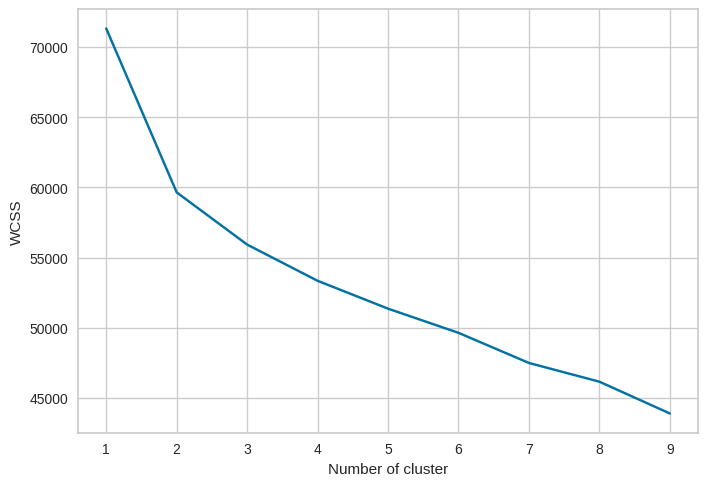

In [ ]:
#Empty dictionary to store the SSE for each value of k
WCSS = {}

# iterate for a range of Ks and fit the scaled data to the algorithm. Use inertia attribute from the clustering object and
# store the inertia value for that k

#remove ___________ and write the complete the code
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(data_scaled)
    WCSS[k] = kmeans.inertia_

#Elbow plot
plt.figure()
plt.plot(list(WCSS.keys()), list(WCSS.values()), 'bx-')
plt.xlabel("Number of cluster")
plt.ylabel("WCSS")
plt.show()

##### **Observations:**

The elbow plot shows a significant drop in WCSS between one and two clusters, indicating that dividing the data into two groups captures a large portion of the overall variance. After this point, the decrease in WCSS becomes more gradual, suggesting diminishing returns from adding more clusters. Still, it's a good idea to check this result with another method, like the silhouette score, to make sure it's the best option.

#### **Question 8** : finalize appropriate number of clusters by checking the silhoutte score as well. Is the answer different from the elbow plot?

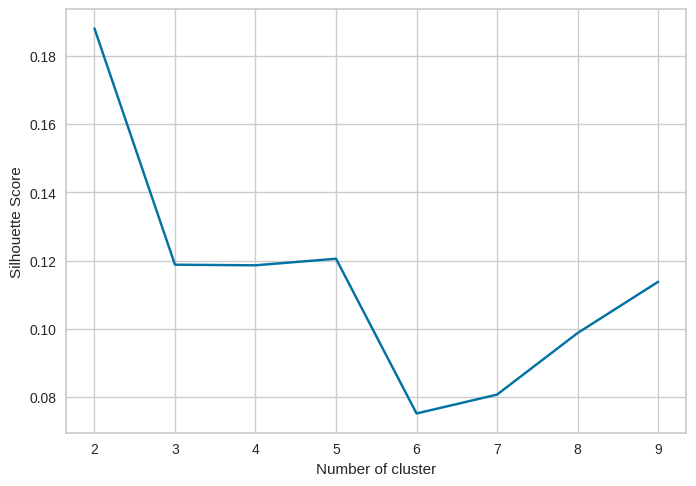

In [ ]:
# Empty dictionary to store the Silhouette score for each value of k
silhouette_scores = {}

# Iterate for a range of Ks and fit the scaled data to the algorithm.
# Calculate the silhouette score for each k and store it.
for k in range(2, 10): # Silhouette score is not defined for k=1
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(data_scaled)
    silhouette_scores[k] = silhouette_score(data_scaled, kmeans.labels_)

# Plot the silhouette scores
plt.figure()
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), 'bx-')
plt.xlabel("Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()


##### **Observations:**

The silhouette plot shows that the highest score occurs at k = 2, indicating the best-defined cluster separation at this point. As the number of clusters increases, the silhouette score gradually decreases, suggesting that additional clusters lead to less distinct and more overlapping groups. Therefore, k = 2 appears to be the most appropriate choice for achieving well-separated clusters.

In [ ]:
data_scaled.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_Tenure,Age,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow
0,0.288916,-0.824830,-0.930009,0.304678,0.981897,1.553973,1.677867,2.470116,1.472821,0.850550,0.350772,1.409757,2.511018,-0.552281,0.693286,-0.279954,-0.284586,-0.279022,-0.261825,-0.116801,-0.095152,2.394606,1.503069,1.016111,-0.157568,0.991512,-0.444683,-0.525263,-0.795592,1.911399,-0.591685,-0.189158
1,-0.261604,1.032287,0.906120,-0.386159,-0.870437,-0.636301,-0.713690,-0.650938,-0.632110,-0.729684,-0.166680,-1.110458,-0.569178,-1.166876,-0.131332,-0.279954,-0.284586,-0.279022,-0.261825,-0.116801,-0.095152,-0.417605,-1.421715,1.272633,-0.157568,0.991512,-0.444683,-0.525263,-0.795592,1.911399,-0.591685,-0.189158
2,0.917903,-0.824830,-0.930009,-0.800660,0.361484,0.572126,-0.177804,1.350208,-0.148218,-0.035923,-0.684133,1.409757,-0.226934,1.291504,-0.543642,-0.279954,-0.284586,-0.279022,-0.261825,-0.116801,-0.095152,-0.417605,0.040677,0.332055,-0.157568,0.991512,-0.444683,-0.525263,-0.795592,-0.523177,1.690089,-0.189158
3,-1.181068,1.032287,-0.930009,-0.800660,-0.870437,-0.560775,-0.651686,-0.504065,-0.583721,-0.748955,-0.166680,-0.750427,-0.911423,-0.552281,0.280977,-0.279954,-0.284586,-0.279022,-0.261825,-0.116801,-0.095152,-0.417605,-1.421715,-1.292580,-0.157568,0.991512,-0.444683,-0.525263,-0.795592,-0.523177,1.690089,-0.189158
4,0.296151,1.032287,-0.930009,1.548183,-0.389542,0.421072,-0.217663,0.156864,-0.003050,-0.556244,1.385676,0.329665,0.115310,0.062314,-0.131332,-0.279954,-0.284586,-0.279022,-0.261825,-0.116801,-0.095152,-0.417605,-1.421715,-1.036059,-0.157568,-1.008561,-0.444683,1.903807,1.256925,-0.523177,-0.591685,-0.189158


#### **Question 9**: Do a final fit with the appropriate number of clusters. How much total time does it take for the model to fit the data?

In [ ]:
import time
from sklearn.cluster import KMeans

# Define the number of clusters
n_clusters = 2

# Initialize and fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)

# Measure the time taken to fit the model
start_time = time.time()
kmeans.fit(data_scaled)
end_time = time.time()

# Get the cluster labels
cluster_labels = kmeans.labels_

# Print the time taken
print(f"Time taken to fit the KMeans model with {n_clusters} clusters: {end_time - start_time:.4f} seconds")

# Add the cluster labels to the original data
data['Cluster'] = cluster_labels

# Display the first few rows with the new cluster labels
display(data.head())

Time taken to fit the KMeans model with 2 clusters: 0.0361 seconds


,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_Tenure,Age,Cluster
0,5524,Graduation,Single,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,13,68,0
1,2174,Graduation,Single,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,11,71,1
2,4141,Graduation,Together,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,12,60,0
3,6182,Graduation,Together,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,11,41,1
4,5324,PhD,Married,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,11,44,1


In [ ]:
# Perform value counts on the 'Cluster' column
cluster_counts = data['Cluster'].value_counts()

# Display the cluster counts
print("Distribution of data points across clusters:")
display(cluster_counts)

Distribution of data points across clusters:


,count
Cluster,
1,1344
0,885


##### **Observations:**

After applying K-Means with k = 2, we observed that the data is distributed into two clusters, with 1,347 records in one cluster and 889 in the other. The init='k-means++' parameter is used to improve the initialization of cluster centroids in the K-Means algorithm. Instead of selecting all initial centroids randomly, K-Means++ chooses them in a way that spreads them out across the data space.

## **Cluster Profiling and Comparison**

#### **Question 10**: Perform cluster profiling using boxplots for the K-Means algorithm. Analyze key characteristics of each cluster and provide detailed observations.

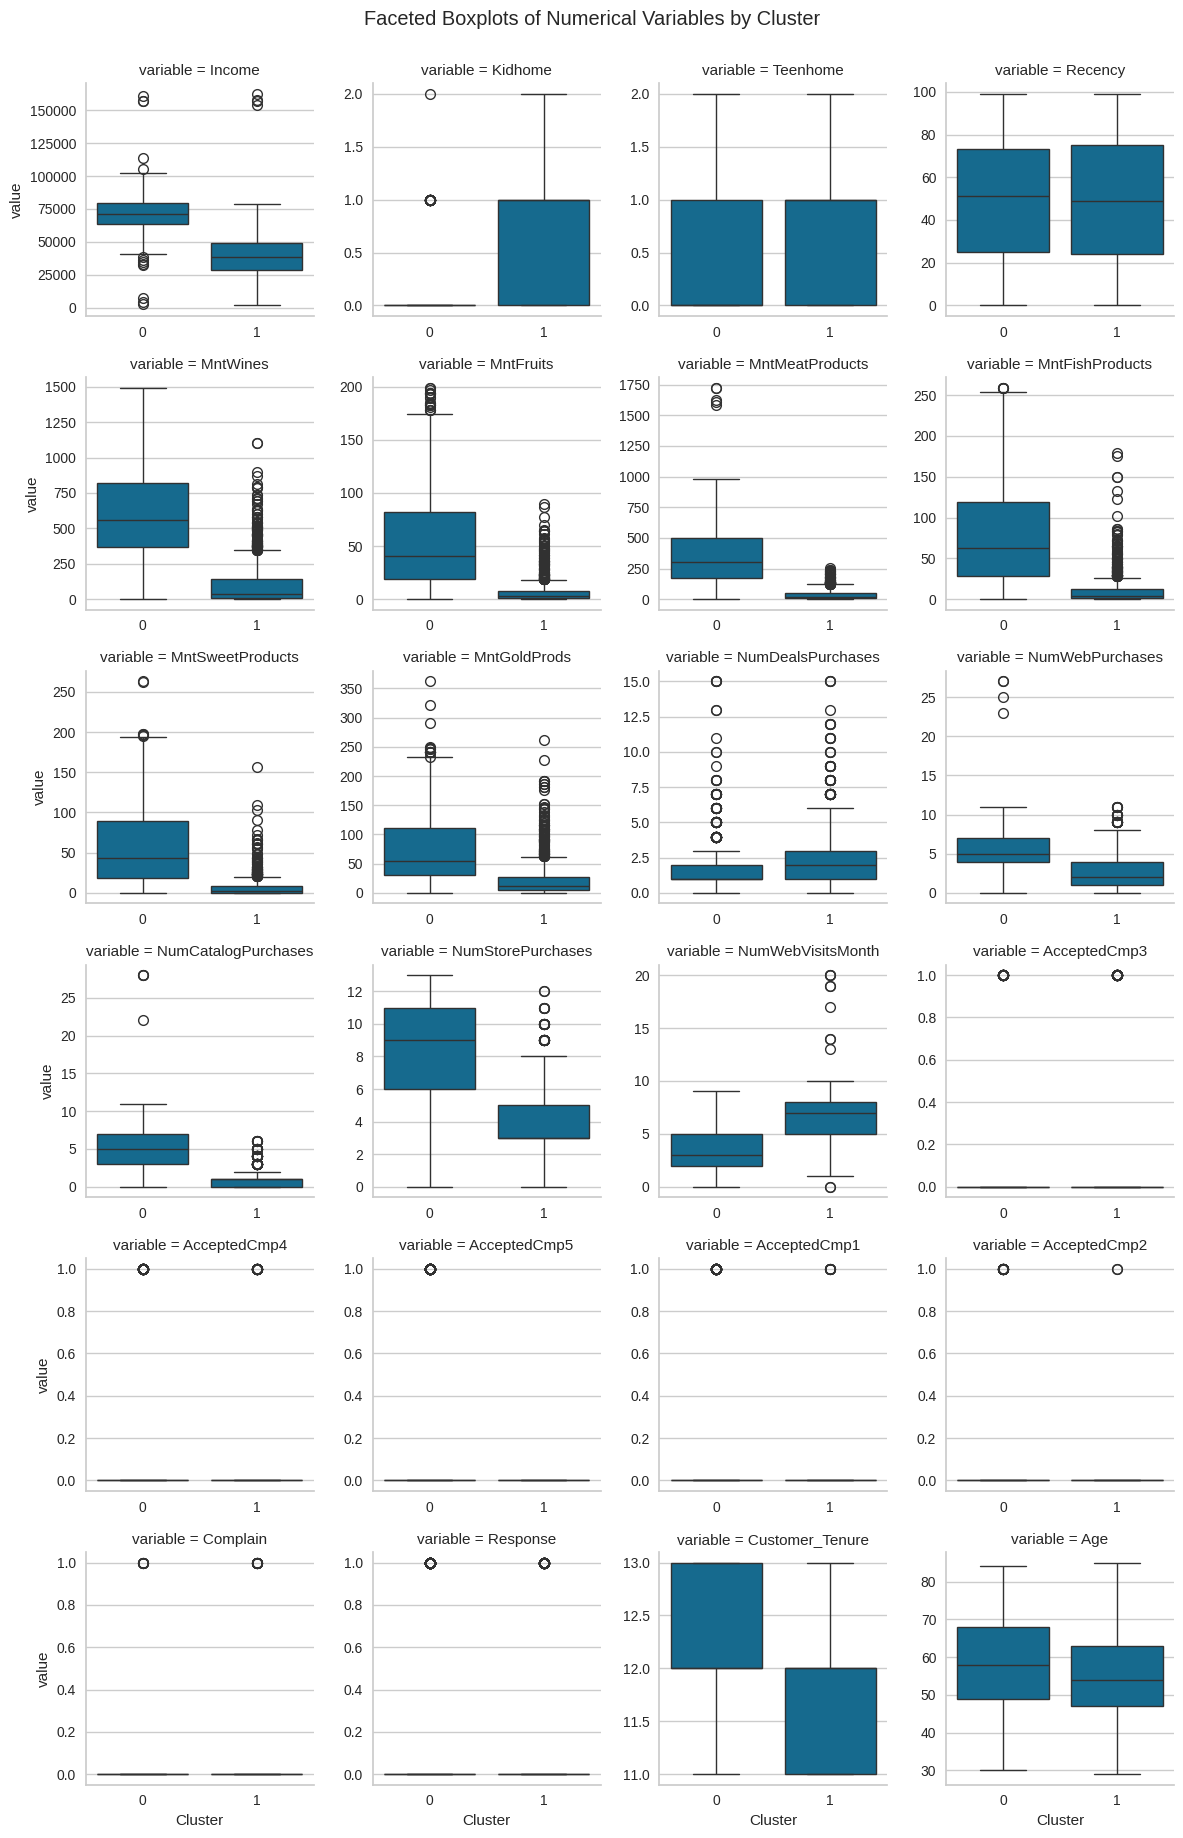

In [ ]:
# Select numerical columns for cluster profiling (excluding 'Cluster', 'ID', 'Z_CostContact', 'Z_Revenue')
numerical_cols = data.select_dtypes(include=np.number).columns.tolist()
cols_to_exclude = ['Cluster', 'ID', 'Z_CostContact', 'Z_Revenue']
numerical_cols = [col for col in numerical_cols if col not in cols_to_exclude]


# Create faceted boxplots
g = sns.FacetGrid(data.melt(id_vars='Cluster', value_vars=numerical_cols), col="variable", col_wrap=4, sharex=False, sharey=False)
g.map(sns.boxplot, "Cluster", "value")
plt.suptitle('Faceted Boxplots of Numerical Variables by Cluster', y=1.02)
plt.show()

##### **Observations:**

The boxplots show clear behavioral and demographic differences between the two clusters. Cluster 0 is characterized by higher income levels and greater spending across all product categories, including wines, meat, fruits, fish, sweets, and gold products. These customers also make more purchases through all available channels such as the web, catalog, and physical stores, suggesting they are more active and engaged. In contrast, Cluster 1 displays lower income, lower spending, and fewer purchases overall, indicating a less engaged or lower-value customer segment.

Regarding Customer_Tenure, Cluster 0 shows slightly higher tenure values, meaning these customers have generally been with the company longer. This suggests stronger loyalty or a more established relationship with the brand. Cluster 1, on the other hand, includes customers with shorter tenure, which may reflect more recent acquisitions or less established relationships.

Both clusters exhibit similar patterns in recency, campaign acceptance, complaints, and age, implying that these variables do not play a major role in distinguishing the groups. Overall, the segmentation primarily differentiates customers based on income, spending behavior, and tenure, forming two meaningful groups: Cluster 0 representing long-term, high-value, and active customers, and Cluster 1 representing newer, lower-value, and less engaged customers.

#### **Question 11**: Perform cluster profiling on the data using a barplot for the K-Means algorithm. Provide insights and key observations for each cluster based on the visual analysis.

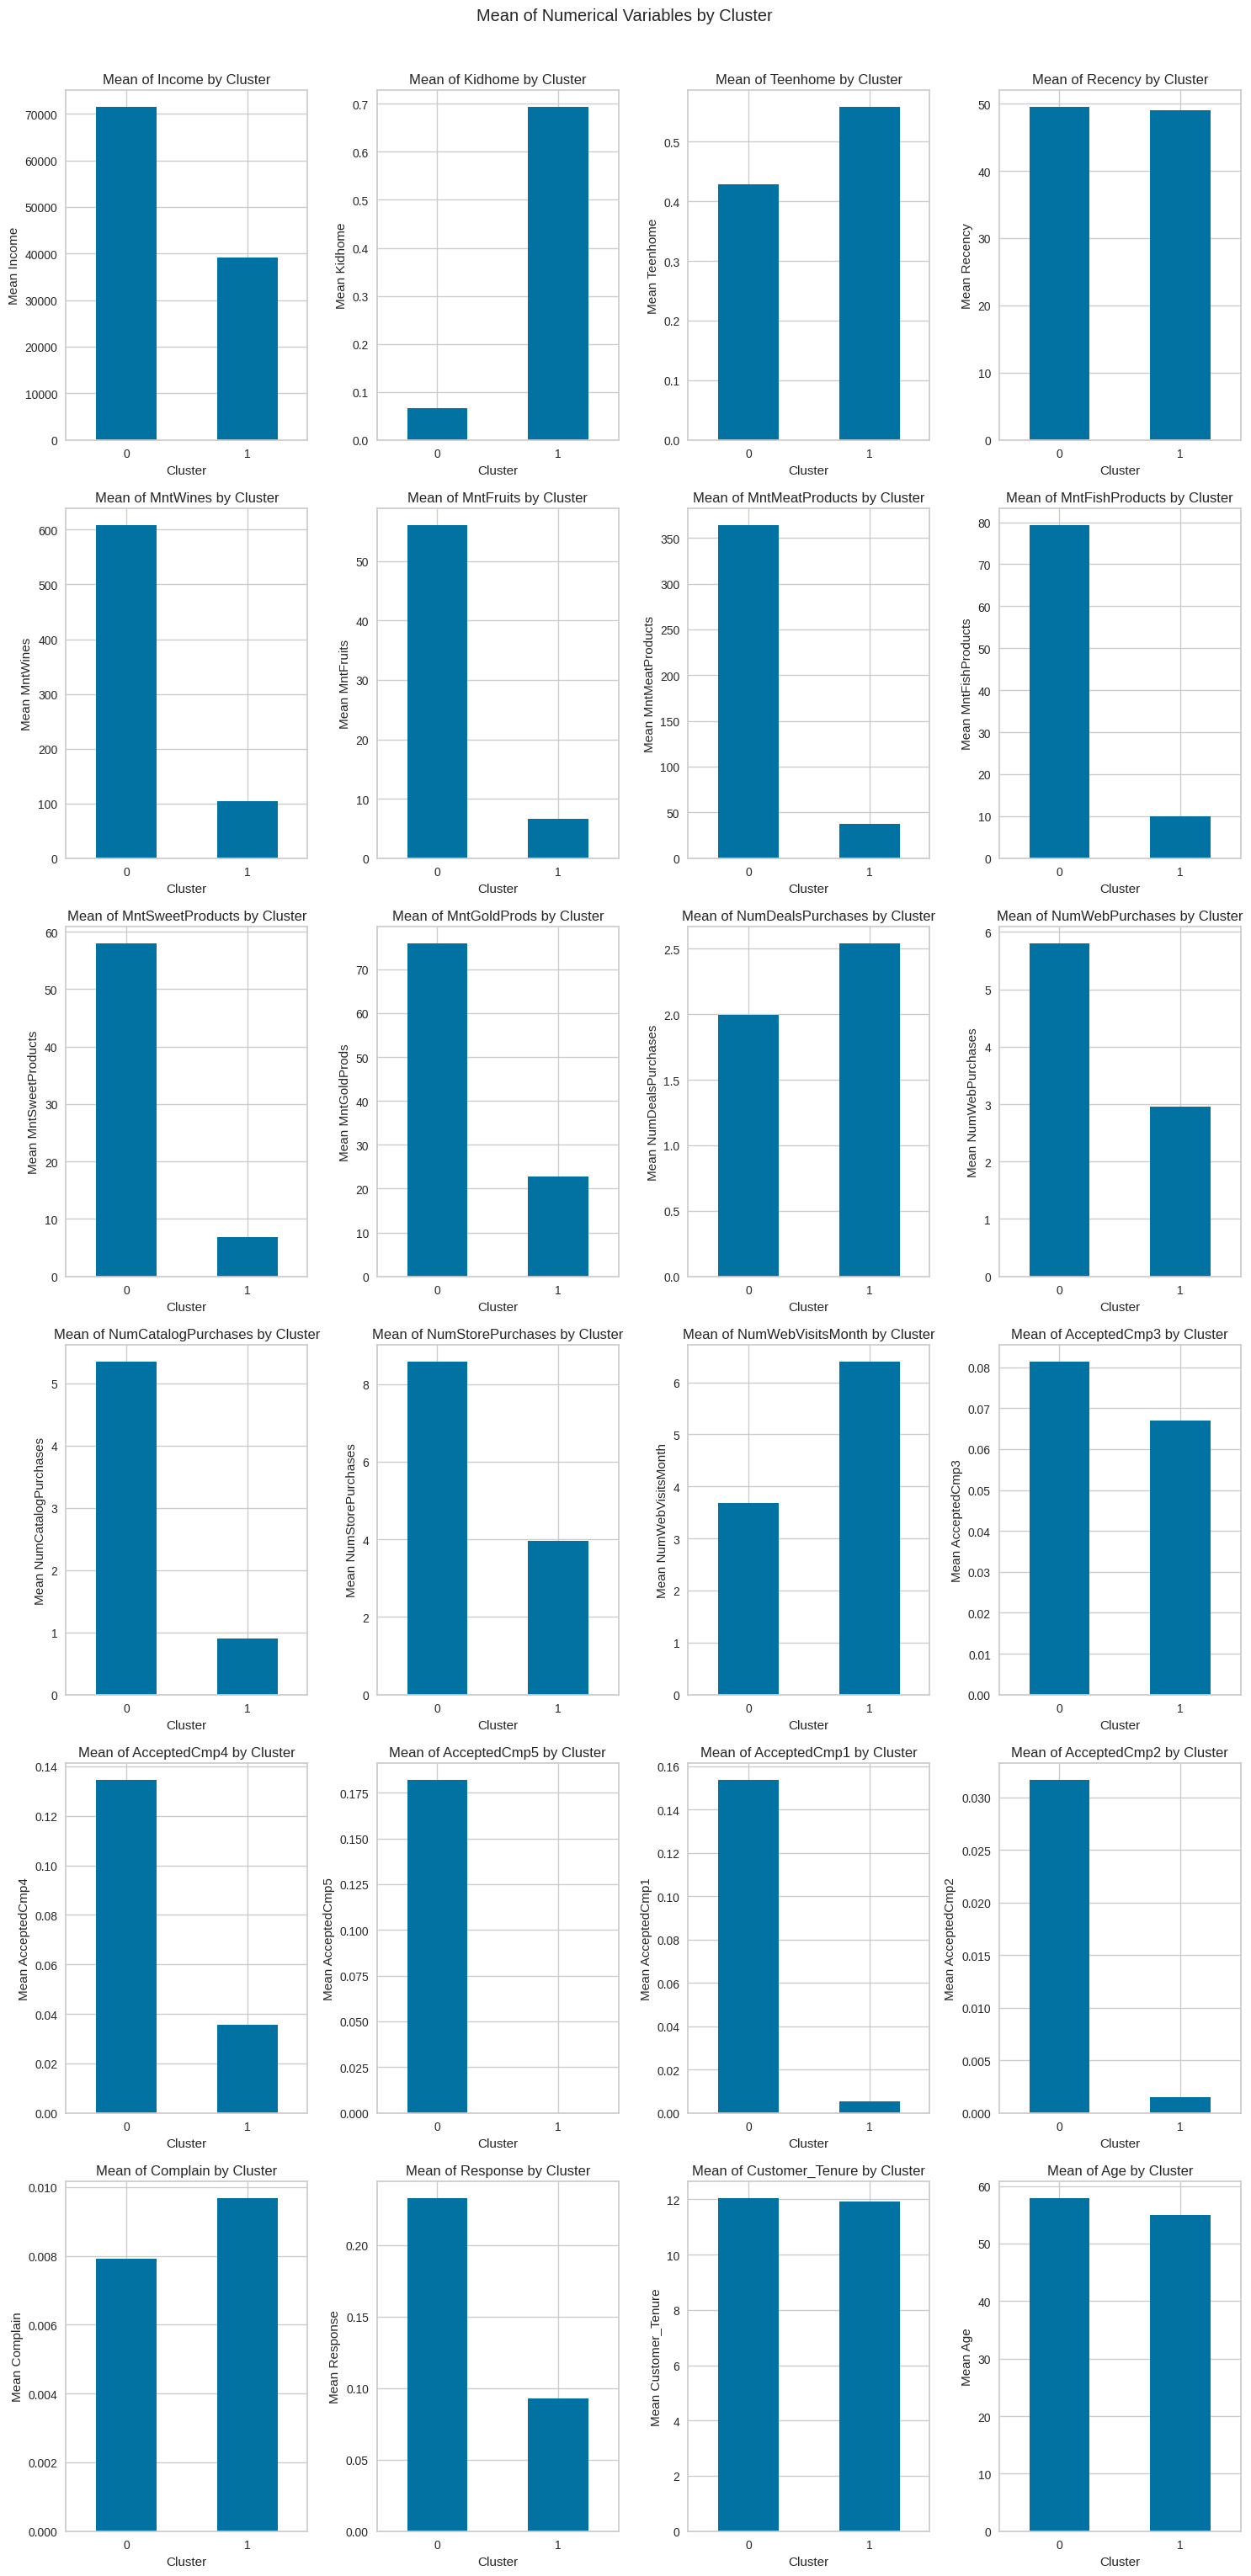

In [ ]:
# Calculate the mean of numerical features for each cluster
cluster_means = data.groupby('Cluster')[numerical_cols].mean()

# Plot bar plots for the mean of numerical features for each cluster in a grid
num_cols = len(numerical_cols)
n_cols = 4  # Adjust the number of columns in the grid as needed
n_rows = (num_cols + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    cluster_means[col].plot(kind='bar')
    plt.title(f'Mean of {col} by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(f'Mean {col}')
    plt.xticks(rotation=0)
plt.tight_layout()
plt.suptitle('Mean of Numerical Variables by Cluster', y=1.02)
plt.show()

##### **Observations:**

The mean comparison of numerical variables across clusters confirms the distinction between the two groups. Cluster 0 customers have a much higher average income and spend more across all product categories, including wines, meat, fruits, fish, sweets, and gold products. They also make more purchases through catalogs and physical stores, highlighting a stronger engagement with the company's offerings. Cluster 1 customers, on the other hand, have lower income and considerably lower spending levels, reflecting limited engagement and purchasing activity.

Cluster 1 shows slightly higher averages in the number of children and teenagers at home, which could influence their lower spending behavior. In terms of marketing responses, Cluster 0 has higher acceptance rates across most campaigns, suggesting greater responsiveness and interest. Both clusters exhibit similar values for recency and age, indicating that these variables do not strongly differentiate them.

Overall, Cluster 0 represents high-income, high-spending, and responsive customers, while Cluster 1 includes lower-income, less active, and less responsive customers.

#### Clusters by Education and Marital Status

Education distribution within each cluster:


Education,2n Cycle,Basic,Graduation,Master,PhD
Cluster,,,,,
0,0.084746,0.001130,0.532203,0.148023,0.233898
1,0.093750,0.039435,0.485863,0.176339,0.204613


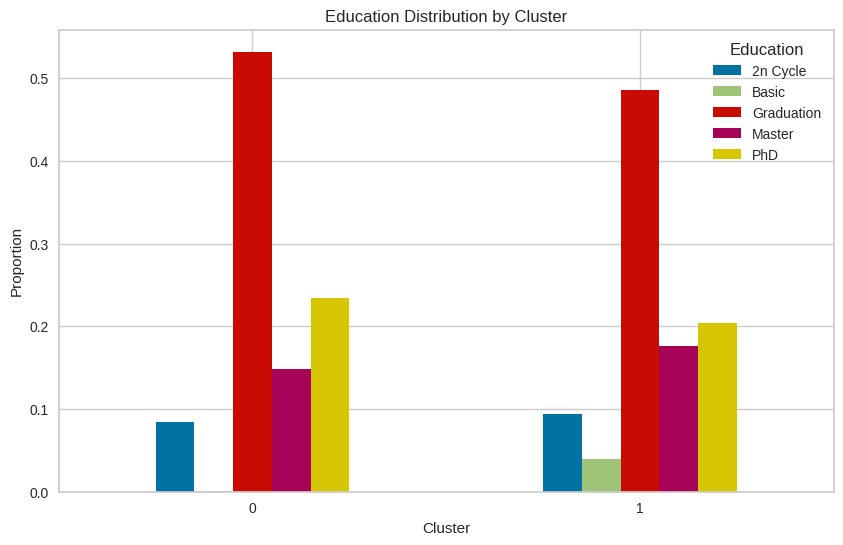


Marital Status distribution within each cluster:


Marital_Status,Divorced,Married,Single,Together,Widow
Cluster,,,,,
0,0.114124,0.370621,0.213559,0.256497,0.045198
1,0.096726,0.398810,0.215774,0.261161,0.027530


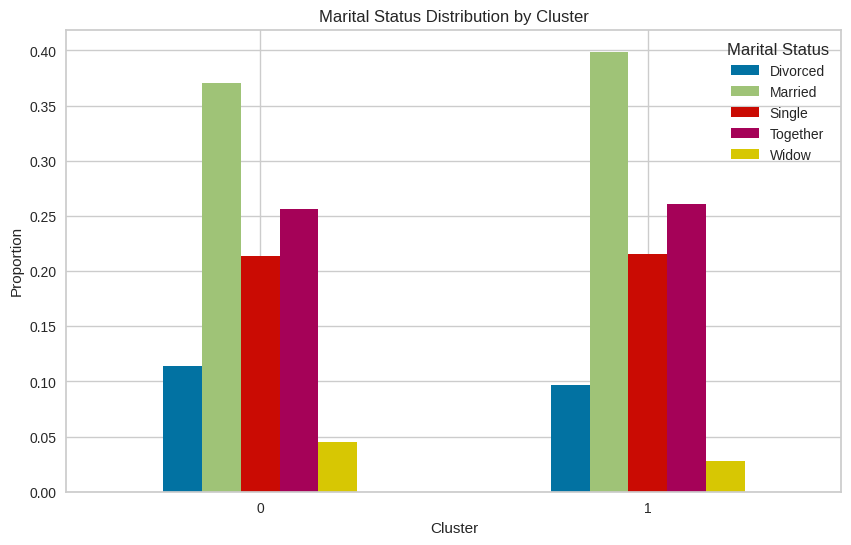

In [ ]:
# Analyze Education distribution within each cluster
education_cluster = data.groupby('Cluster')['Education'].value_counts(normalize=True).unstack()
print("Education distribution within each cluster:")
display(education_cluster)

# Plot the Education distribution
education_cluster.plot(kind='bar', figsize=(10, 6))
plt.title('Education Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Education')
plt.show()

# Analyze Marital Status distribution within each cluster
marital_cluster = data.groupby('Cluster')['Marital_Status'].value_counts(normalize=True).unstack()
print("\nMarital Status distribution within each cluster:")
display(marital_cluster)

# Plot the Marital Status distribution
marital_cluster.plot(kind='bar', figsize=(10, 6))
plt.title('Marital Status Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Marital Status')
plt.show()

#### **Observations:**

Regarding the education levels across the two clusters, in both of them the majority of customers hold a Graduation degree, followed by those with a PhD and a Master's degree. The proportions of 2nd Cycle and Basic education levels are notably smaller.

Cluster 0 has a slightly higher proportion of PhD holders compared to Cluster 1, while Cluster 1 shows a marginally larger share of customers with Basic education. Overall, both clusters are composed mainly of highly educated customers, suggesting that education level does not strongly differentiate the clusters, though Cluster 0 appears to include a slightly more academically advanced segment.

As for marital status, in both clusters the majority of customers are Married, followed by those who are Together and Single. Smaller proportions are Divorced and Widow. The distributions are very similar between clusters, with only slight differences. Cluster 1 has a slightly higher proportion of Married individuals, while Cluster 0 shows a marginally greater share of Divorced customers. Overall, marital status does not appear to be a strong differentiating factor between the two clusters, as both display comparable patterns in their composition.



## **Business Recommedations**

#### **Question 12**: Based on the cluster insights, what business recommendations can be provided?

Based on the characteristics identified for each cluster, the following business recommendations can be provided.

*   **Cluster 0** represents *high-value and engaged customers*. This group has
higher income levels and spends significantly more across all product categories, particularly on premium items such as wine and meat. They make more purchases through all channels, including web, catalog, and store, show slightly higher customer tenure, and demonstrate stronger responsiveness to marketing campaigns.

    * For these customers, the business should focus on developing loyalty programs, exclusive offers, and personalized product recommendations that highlight premium categories.
    
    * Retention strategies such as exceptional customer service, personalized communication, and exclusive events or early access to new products can help strengthen their loyalty.

    * Cross-selling and upselling opportunities should be explored by promoting complementary or higher-end products based on past purchase behavior.

    * Additionally, maintaining a seamless and premium multichannel experience will reinforce their satisfaction and engagement with the brand. Encouraging brand advocacy through referrals or social media engagement can further enhance customer value and strengthen the company's market position.



*   **Cluster 1** consists of *lower-value and less engaged customers*. These individuals generally have lower income and spending levels, make fewer purchases, and often have more children or teenagers at home. They also tend to have shorter customer tenure and lower response rates to marketing campaigns.

    * For this group, the company should prioritize value-oriented strategies such as offering discounts, promotional bundles, and loyalty points to increase purchase frequency.
    
    * Marketing campaigns should focus on practicality and affordability, promoting family-friendly or budget-conscious products that align with their needs.
    
    * Re-engagement efforts, including personalized email campaigns, reminders, and incentives for repeat purchases, can help strengthen their connection with the brand.
    
    * Simplifying the shopping experience across all channels and offering clear product information will make the process more convenient and appealing.
    
    * Over time, educational or trust-building communication can help these customers become more familiar and comfortable with the brand, potentially leading to greater engagement.

Overall, the company should aim to retain and nurture Cluster 0 customers through premium experiences and loyalty incentives, while re-engaging Cluster 1 customers with value-driven offers and targeted marketing strategies. This dual approach will enhance both customer satisfaction and long-term profitability.




























## **Next steps**

In order to strengthen the analysis, future work could include testing other clustering algorithms such as Hierarchical Clustering or DBSCAN to validate the segment stability. Additional variables like customer lifetime value, churn risk, or marketing channel usage could enrich the segmentation and make it more actionable. The current clusters can be integrated into CRM systems to personalize marketing campaigns and track results through A/B testing. Finally, it is important to periodically update the clusters as new data becomes available and monitor key performance indicators such as spending patterns, engagement frequency, and retention rates to evaluate the effectiveness of targeted strategies.










































---------------------------------------------------------------------------